# Business Objective Discussion

Objective: Predict Reliance Industries' stock closing price for the next 30 days.

Activities:

* Understand business problem.
* Define forecasting objective.
* Identify required data: Date, Open, High, Low, Close, Volume.
* Collect historical Reliance Industries stock data.
* Define training and testing strategy.
* Plan model evaluation metrics: MAE, RMSE, MAPE.
* Final output: 30-day stock-price forecast.

# EDA — Exploratory Data Analysis

In [1]:
# Libraries

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

In [2]:
# Data loading

df = pd.read_excel("Company stock prices.xlsx")

df.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-10-19,537.070007,541.799988,525.380005,530.719971,530.719971,7567500
1,2020-10-20,528.140015,533.780029,522.260010,525.419983,525.419983,10047200
2,2020-10-21,501.029999,506.850006,488.250000,489.049988,489.049988,17405700
3,2020-10-22,494.690002,495.140015,482.000000,485.230011,485.230011,6997900
4,2020-10-23,488.109985,490.059998,481.350006,488.279999,488.279999,4927900


In [3]:
df.shape


(753, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       753 non-null    datetime64[ns]
 1   Open       753 non-null    float64       
 2   High       753 non-null    float64       
 3   Low        753 non-null    float64       
 4   Close      753 non-null    float64       
 5   Adj Close  753 non-null    float64       
 6   Volume     753 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 41.3 KB


In [5]:
# Data preprocessing
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df = df.set_index('Date')


In [6]:
# Check duplicate values
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
# Remove duplicates
df = df[~df.index.duplicated(keep='first')]

In [8]:
# Select important columns
df = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']]

In [9]:
# Missing-value treatment
print(df.isnull().sum())
df = df.ffill()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [10]:
# Descriptive statistics
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,753.000000,753.000000,753.000000,753.000000,753.000000,7.530000e+02
mean,414.903107,421.117954,408.519270,414.796653,414.796653,7.060370e+06
std,135.039753,135.568500,134.016834,134.669664,134.669664,7.470407e+06
min,163.960007,172.059998,162.710007,166.369995,166.369995,1.144000e+06
25%,311.570007,319.799988,308.850006,313.480011,313.480011,3.629200e+06
50%,418.399994,425.260010,411.880005,416.029999,416.029999,5.277700e+06
75%,519.900024,526.380005,513.789978,519.780029,519.780029,7.973300e+06
max,692.349976,700.989990,686.090027,691.690002,691.690002,1.333875e+08


# Visualization

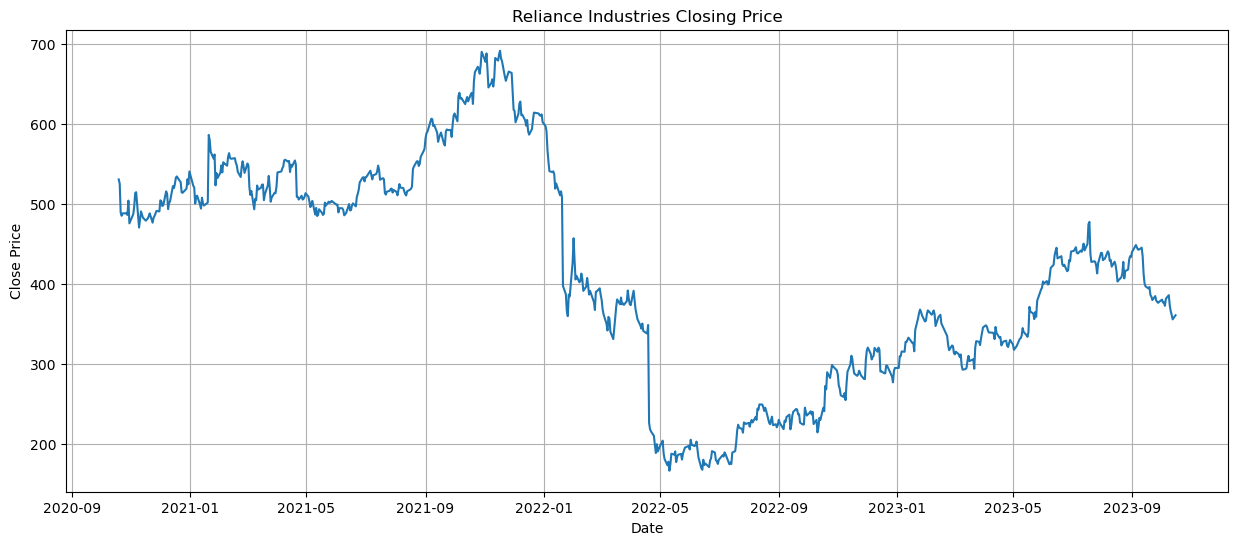

In [11]:
# Closing-price trend

plt.figure(figsize=(15,6))

plt.plot(df['Close'])

plt.title("Reliance Industries Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.grid()
plt.show()

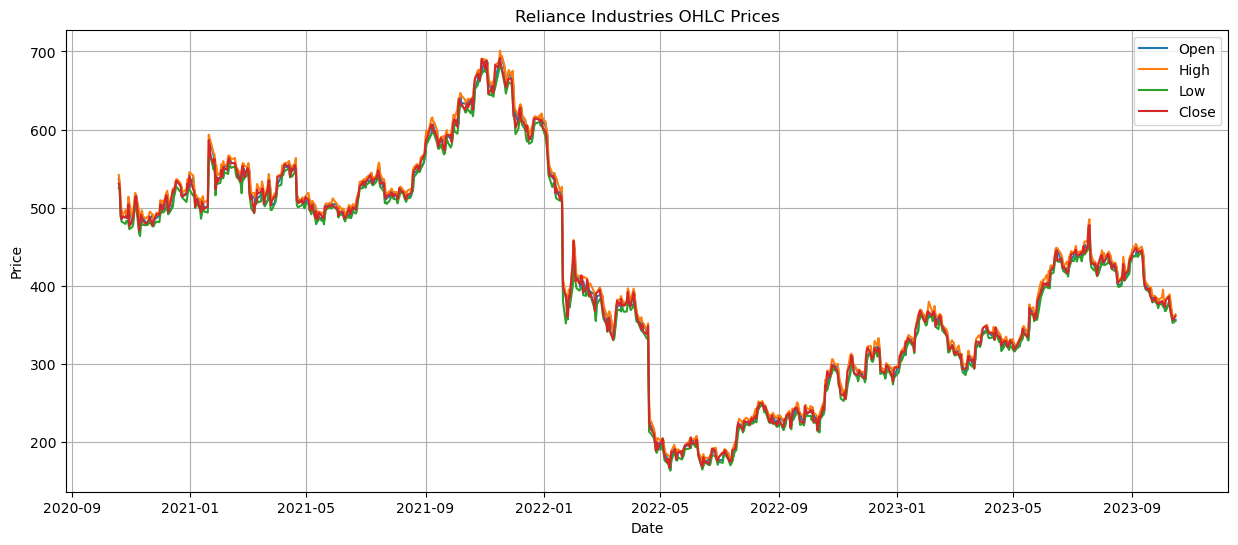

In [12]:
# OHLC analysis

plt.figure(figsize=(15,6))

plt.plot(df['Open'], label='Open')
plt.plot(df['High'], label='High')
plt.plot(df['Low'], label='Low')
plt.plot(df['Close'], label='Close')

plt.title("Reliance Industries OHLC Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

In [13]:
# Daily returns
# Daily returns are important for understanding volatility

df['Daily_Return'] = df['Close'].pct_change()

df['Daily_Return'].describe()

count    752.000000
mean      -0.000005
std        0.031014
min       -0.351166
25%       -0.014059
50%        0.000368
75%        0.013330
max        0.168543
Name: Daily_Return, dtype: float64

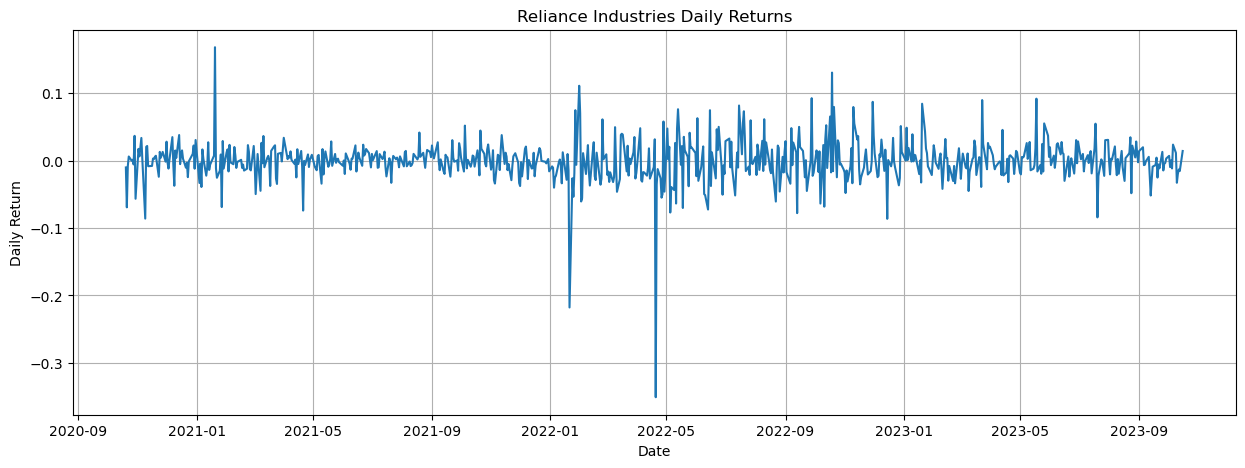

In [14]:
#Plot:

plt.figure(figsize=(15,5))

plt.plot(df.index, df['Daily_Return'])

plt.title("Reliance Industries Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.grid()
plt.show()

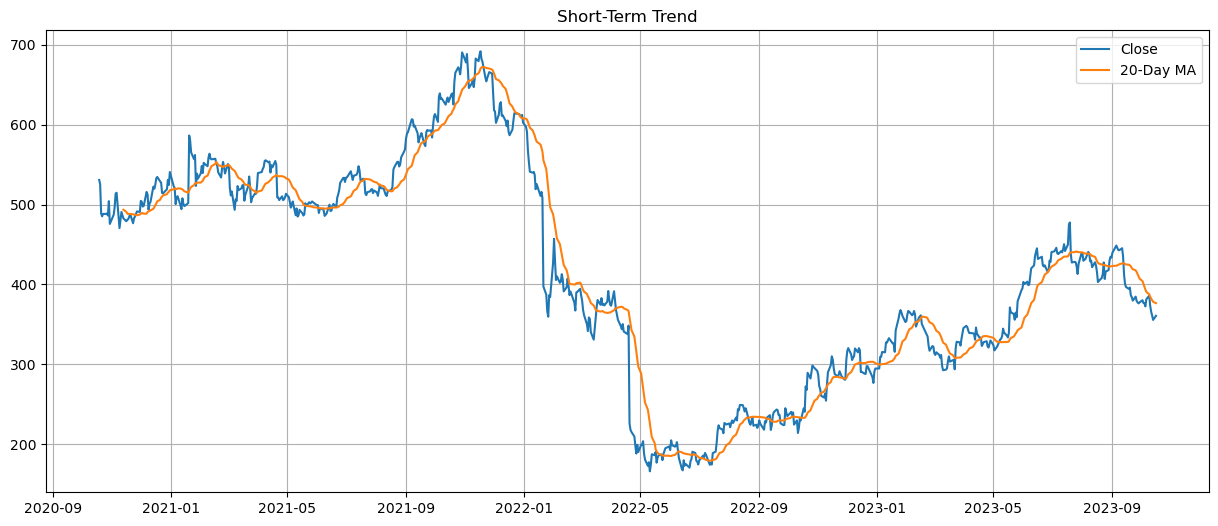

In [15]:
# Short-term trend
# Use a 20-day moving average.

df['MA20'] = df['Close'].rolling(20).mean()

plt.figure(figsize=(15,6))

plt.plot(df['Close'], label='Close')
plt.plot(df['MA20'], label='20-Day MA')

plt.title("Short-Term Trend")
plt.legend()
plt.grid()
plt.show()

*Interpretation*

Close > MA20

     ↓
Short-term bullish trend

Close < MA20

     ↓
Short-term bearish trend

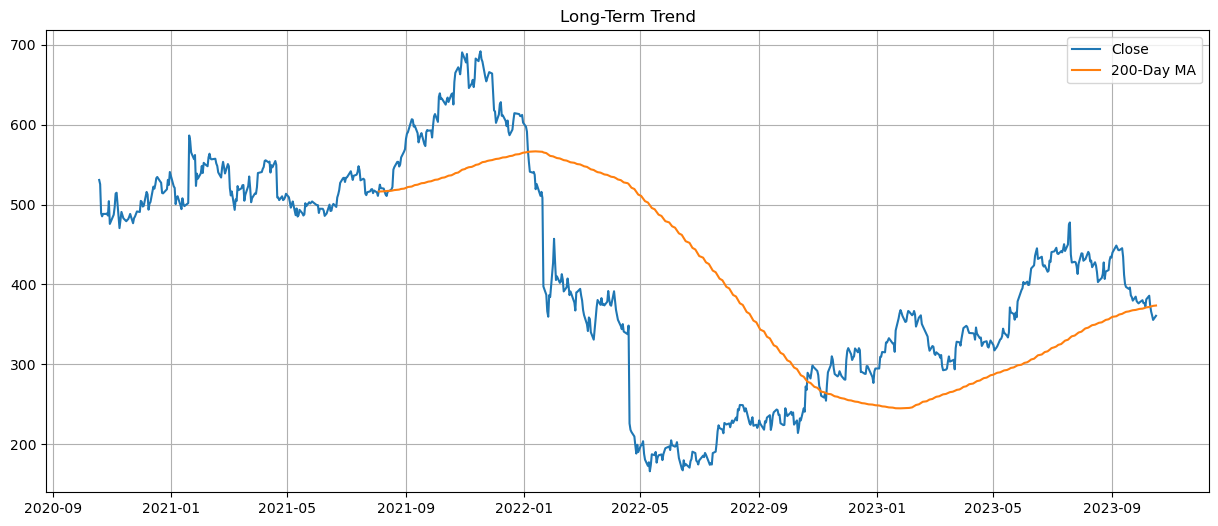

In [16]:
# Long-term trend
# Use a 200-day moving average.

df['MA200'] = df['Close'].rolling(200).mean()

plt.figure(figsize=(15,6))

plt.plot(df['Close'], label='Close')
plt.plot(df['MA200'], label='200-Day MA')

plt.title("Long-Term Trend")
plt.legend()
plt.grid()
plt.show()

*Interpretation*

Close > MA200

     ↓
Short-term bullish trend

Close < MA200

     ↓
Short-term bearish trend

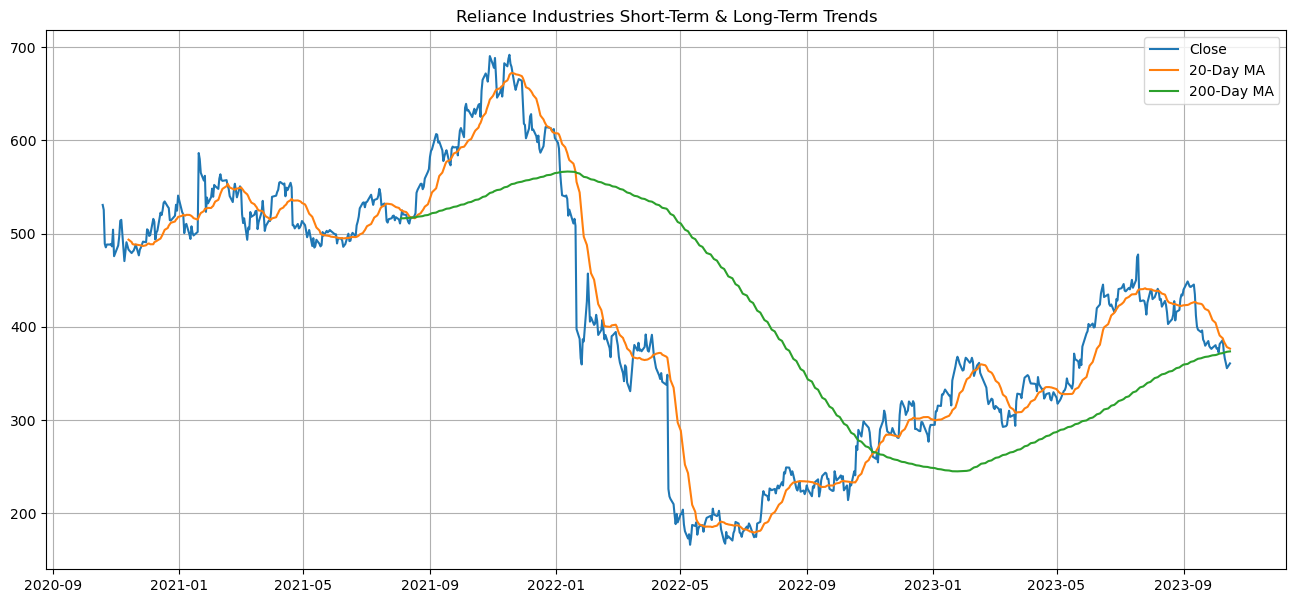

In [17]:
# Combined trend analysis

plt.figure(figsize=(16,7))

plt.plot(df['Close'], label='Close')
plt.plot(df['MA20'], label='20-Day MA')
plt.plot(df['MA200'], label='200-Day MA')

plt.title("Reliance Industries Short-Term & Long-Term Trends")

plt.legend()
plt.grid()
plt.show()

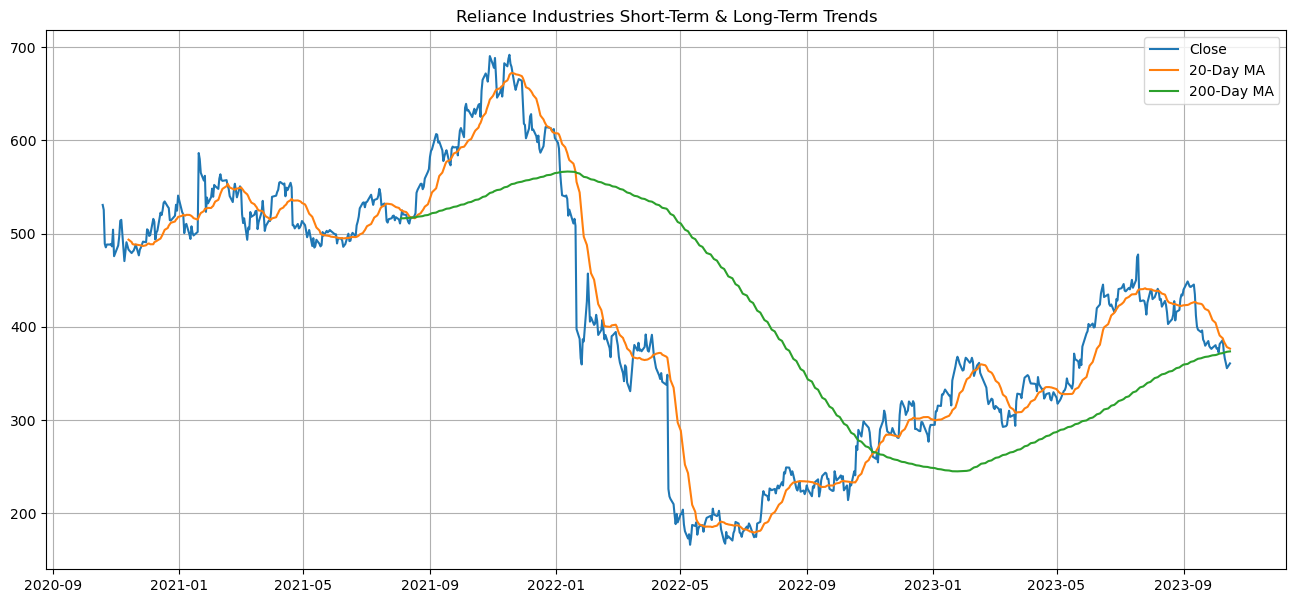

In [18]:
# Volume analysis
# compare unusual volume spikes with major price movements.

plt.figure(figsize=(16,7))

plt.plot(df['Close'], label='Close')
plt.plot(df['MA20'], label='20-Day MA')
plt.plot(df['MA200'], label='200-Day MA')

plt.title("Reliance Industries Short-Term & Long-Term Trends")

plt.legend()
plt.grid()
plt.show()

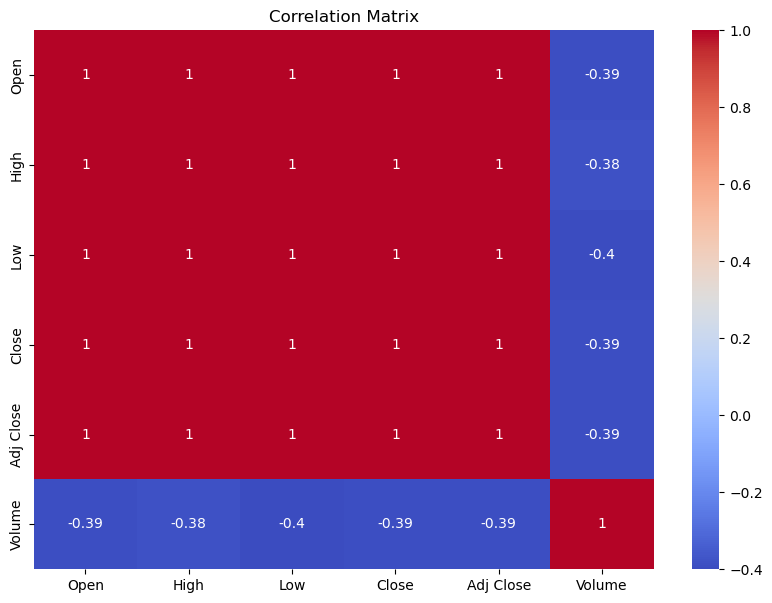

In [19]:
# Correlation analysis

plt.figure(figsize=(10,7))

sns.heatmap(
    df[['Open','High','Low','Close','Adj Close','Volume']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

# EDA conclusion

* Overall stock-price movement.
* Short-term trend using 20-day moving average.
* Long-term trend using 200-day moving average.
* Volatility using daily returns.
* Relationship between Open, High, Low, Close and Volume.
* Major price movements and possible external events.

# Model Building and Model Evaluation

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [21]:
# Select target
# Prepare data for time-series model
# We will forecast Close price.
data = df[['Close']].copy()

In [22]:
# Train-test split
# last year to be used as the test set.
# For daily stock data, approximately 252 trading days represent one year.

test_size = 252

train = data.iloc[:-test_size]
test = data.iloc[-test_size:]

print("Training data:", train.shape)
print("Testing data:", test.shape)

print("Train:", train.index.min(), "to", train.index.max())
print("Test :", test.index.min(), "to", test.index.max())

Training data: (501, 1)
Testing data: (252, 1)
Train: 2020-10-19 00:00:00 to 2022-10-13 00:00:00
Test : 2022-10-14 00:00:00 to 2023-10-16 00:00:00


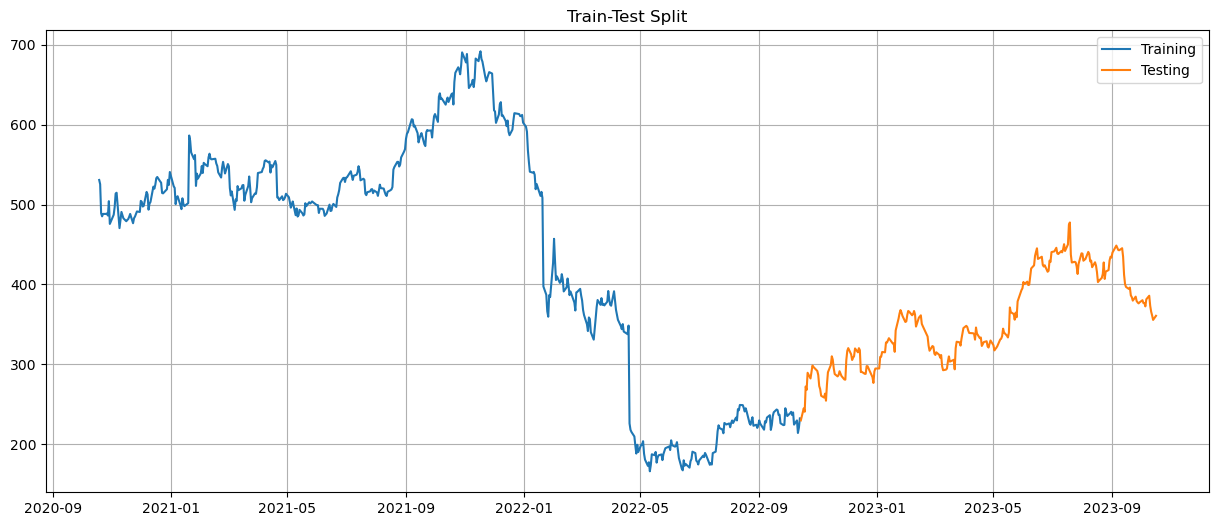

In [23]:
# Visualization:

plt.figure(figsize=(15,6))

plt.plot(train.index, train['Close'], label='Training')
plt.plot(test.index, test['Close'], label='Testing')

plt.title("Train-Test Split")
plt.legend()
plt.grid()
plt.show()

In [24]:
# Model 1 — Naive Forecast
# This is baseline model.
# It predicts that the next price will be equal to the last observed training price.

naive_pred = np.repeat(
    train['Close'].iloc[-1],
    len(test)
)

naive_pred = pd.Series(
    naive_pred,
    index=test.index
)

In [25]:
# Evaluate:

mae_naive = mean_absolute_error(
    test['Close'],
    naive_pred
)

rmse_naive = np.sqrt(
    mean_squared_error(
        test['Close'],
        naive_pred
    )
)

mape_naive = np.mean(
    np.abs(
        (test['Close'] - naive_pred) /
        test['Close']
    )
) * 100

print("Naive MAE :", mae_naive)
print("Naive RMSE:", rmse_naive)
print("Naive MAPE:", mape_naive)

Naive MAE : 123.63413219047618
Naive RMSE: 135.61947319363085
Naive MAPE: 33.083445425827925


I included a naive model as a baseline so that I can determine whether the advanced forecasting models actually improve upon a simple historical-price approach."

In [26]:
# Model 2 — ARIMA

model_arima = ARIMA(
    train['Close'],
    order=(5,1,0)
)

arima_result = model_arima.fit()

print(arima_result.summary())

C:\Users\PALSA MANOJ KUMAR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PALSA MANOJ KUMAR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PALSA MANOJ KUMAR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  501
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -1990.650
Date:                Sat, 22 Aug 2026   AIC                           3993.301
Time:                        23:13:33   BIC                           4018.588
Sample:                             0   HQIC                          4003.224
                                - 501                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0171      0.052      0.329      0.742      -0.085       0.119
ar.L2         -0.0394      0.040     -0.981      0.326      -0.118       0.039
ar.L3          0.0371      0.057      0.647      0.5

In [27]:
# ARIMA prediction

arima_pred = arima_result.forecast(
    steps=len(test)
)

arima_pred.index = test.index

C:\Users\PALSA MANOJ KUMAR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [28]:
# Evaluate ARIMA

mae_arima = mean_absolute_error(
    test['Close'],
    arima_pred
)

rmse_arima = np.sqrt(
    mean_squared_error(
        test['Close'],
        arima_pred
    )
)

mape_arima = np.mean(
    np.abs(
        (test['Close'] - arima_pred) /
        test['Close']
    )
) * 100

print("ARIMA MAE :", mae_arima)
print("ARIMA RMSE:", rmse_arima)
print("ARIMA MAPE:", mape_arima)

ARIMA MAE : 123.93488482857414
ARIMA RMSE: 135.89991492425722
ARIMA MAPE: 33.16907719887331


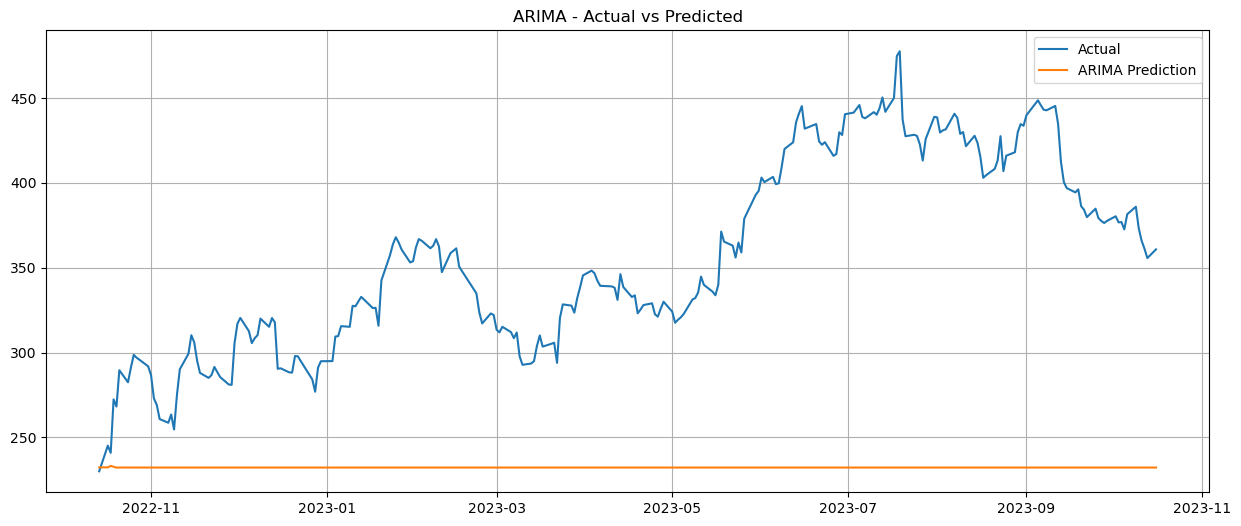

In [29]:
# ARIMA actual vs predicted 

plt.figure(figsize=(15,6))

plt.plot(test.index, test['Close'], label='Actual')
plt.plot(test.index, arima_pred, label='ARIMA Prediction')

plt.title("ARIMA - Actual vs Predicted")
plt.legend()
plt.grid()
plt.show()

In [30]:
# Model 3 — SARIMA

sarima_model = SARIMAX(
    train['Close'],
    order=(1,1,1),
    seasonal_order=(1,1,1,5)
)

sarima_result = sarima_model.fit(
    disp=False
)

print(sarima_result.summary())

C:\Users\PALSA MANOJ KUMAR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PALSA MANOJ KUMAR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                             Close   No. Observations:                  501
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 5)   Log Likelihood               -1984.195
Date:                           Sat, 22 Aug 2026   AIC                           3978.390
Time:                                   23:13:36   BIC                           3999.413
Sample:                                        0   HQIC                          3986.643
                                           - 501                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9157      0.258     -3.548      0.000      -1.421      -0.410
ma.L1          0.9289      0.240      3.863

In [31]:
# SARIMA prediction

sarima_pred = sarima_result.forecast(
    steps=len(test)
)

sarima_pred.index = test.index

C:\Users\PALSA MANOJ KUMAR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [32]:
# Evaluate SARIMA

mae_sarima = mean_absolute_error(
    test['Close'],
    sarima_pred
)

rmse_sarima = np.sqrt(
    mean_squared_error(
        test['Close'],
        sarima_pred
    )
)

mape_sarima = np.mean(
    np.abs(
        (test['Close'] - sarima_pred) /
        test['Close']
    )
) * 100

print("SARIMA MAE :", mae_sarima)
print("SARIMA RMSE:", rmse_sarima)
print("SARIMA MAPE:", mape_sarima)

SARIMA MAE : 217.4169699955807
SARIMA RMSE: 241.07867216853657
SARIMA MAPE: 58.05045349608432


In [33]:
# Model 4 — Exponential Smoothing

ets_model = ExponentialSmoothing(
    train['Close'],
    trend='add',
    seasonal=None
)

ets_result = ets_model.fit()

ets_pred = ets_result.forecast(
    steps=len(test)
)

ets_pred.index = test.index

C:\Users\PALSA MANOJ KUMAR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PALSA MANOJ KUMAR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [34]:
# Evaluate:

mae_ets = mean_absolute_error(
    test['Close'],
    ets_pred
)

rmse_ets = np.sqrt(
    mean_squared_error(
        test['Close'],
        ets_pred
    )
)

mape_ets = np.mean(
    np.abs(
        (test['Close'] - ets_pred) /
        test['Close']
    )
) * 100

print("ETS MAE :", mae_ets)
print("ETS RMSE:", rmse_ets)
print("ETS MAPE:", mape_ets)

ETS MAE : 198.93225991560527
ETS RMSE: 220.285390961673
ETS MAPE: 53.11275776715652


Exponential Smoothing gives more importance to recent observations and is useful for identifying level and trend in time-series data

In [35]:
# Model 5 — LSTM
# LSTM gives you a deep-learning model in addition to traditional statistical models.
# Use the following approach carefully because the LSTM must be evaluated on the last-year test set rather than being trained on the entire dataset.

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(
    train[['Close']]
)

test_scaled = scaler.transform(
    test[['Close']]
)

In [36]:
# Create sequences:

lookback = 60

X_train = []
y_train = []

for i in range(lookback, len(train_scaled)):
    X_train.append(
        train_scaled[i-lookback:i, 0]
    )
    y_train.append(
        train_scaled[i, 0]
    )

X_train = np.array(X_train)
y_train = np.array(y_train)

X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

print(X_train.shape)

(441, 60, 1)


In [38]:
# Build model:

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(lookback, 1)
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(
    LSTM(32)
)

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Train LSTM

history = lstm_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - loss: 0.0954
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0199 
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0136
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0102 
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0084 
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0082 
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - loss: 0.0078
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0079
Epoch 9/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0068 
Epoch 10/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0071 
Epoch 11/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0072
Epoch 12/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0072
Epoch 13/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0065
Epoch 14/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0066
Epoch 15/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.

In [40]:
# For test prediction, construct sequences using the end of the training set plus the test period:

combined = np.concatenate(
    [train_scaled[-lookback:], test_scaled]
)

X_test = []

for i in range(
    lookback,
    len(combined)
):
    X_test.append(
        combined[i-lookback:i, 0]
    )

X_test = np.array(X_test)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

In [41]:
# Predict:

lstm_pred_scaled = lstm_model.predict(
    X_test
)

lstm_pred = scaler.inverse_transform(
    lstm_pred_scaled
).flatten()

lstm_pred = pd.Series(
    lstm_pred,
    index=test.index
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step 


In [42]:
# Evaluate:

mae_lstm = mean_absolute_error(
    test['Close'],
    lstm_pred
)

rmse_lstm = np.sqrt(
    mean_squared_error(
        test['Close'],
        lstm_pred
    )
)

mape_lstm = np.mean(
    np.abs(
        (test['Close'] - lstm_pred) /
        test['Close']
    )
) * 100

print("LSTM MAE :", mae_lstm)
print("LSTM RMSE:", rmse_lstm)
print("LSTM MAPE:", mape_lstm)

LSTM MAE : 20.34466854556129
LSTM RMSE: 24.43107637125931
LSTM MAPE: 5.7245048063531945


In [43]:
# Model comparison

results = pd.DataFrame({
    'Model': [
        'Naive',
        'ARIMA',
        'SARIMA',
        'Exponential Smoothing',
        'LSTM'
    ],
    
    'MAE': [
        mae_naive,
        mae_arima,
        mae_sarima,
        mae_ets,
        mae_lstm
    ],
    
    'RMSE': [
        rmse_naive,
        rmse_arima,
        rmse_sarima,
        rmse_ets,
        rmse_lstm
    ],
    
    'MAPE': [
        mape_naive,
        mape_arima,
        mape_sarima,
        mape_ets,
        mape_lstm
    ]
})

results.sort_values('RMSE')

,Model,MAE,RMSE,MAPE
4,LSTM,20.344669,24.431076,5.724505
0,Naive,123.634132,135.619473,33.083445
1,ARIMA,123.934885,135.899915,33.169077
3,Exponential Smoothing,198.932260,220.285391,53.112758
2,SARIMA,217.416970,241.078672,58.050453


In [44]:
# Model selection

best_model_name = results.loc[
    results['RMSE'].idxmin(),
    'Model'
]

print("Best Model:", best_model_name)

Best Model: LSTM


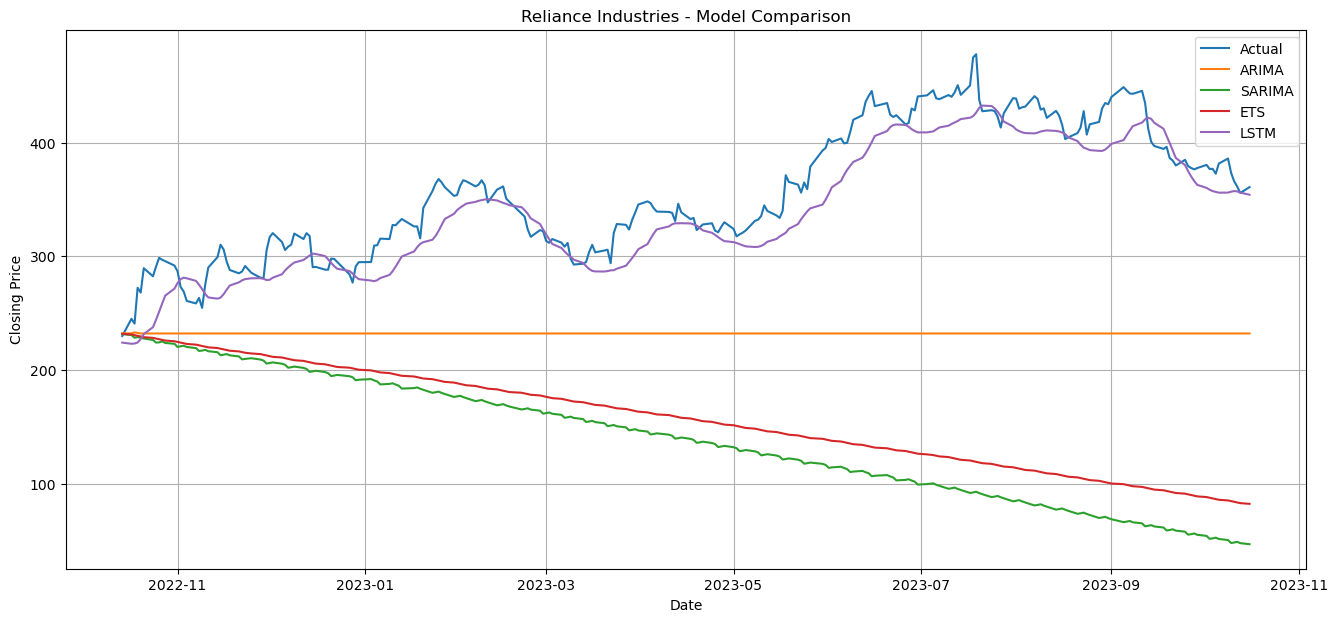

In [45]:
# Compare Predictions Visually

plt.figure(figsize=(16,7))

plt.plot(
    test.index,
    test['Close'],
    label='Actual'
)

plt.plot(
    test.index,
    arima_pred,
    label='ARIMA'
)

plt.plot(
    test.index,
    sarima_pred,
    label='SARIMA'
)

plt.plot(
    test.index,
    ets_pred,
    label='ETS'
)

plt.plot(
    test.index,
    lstm_pred,
    label='LSTM'
)

plt.title(
    "Reliance Industries - Model Comparison"
)

plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()
plt.grid()

plt.show()

In [46]:
# Retrain LSTM on the full dataset
# Because already used the last year as the test set for evaluation, 
# now train the final LSTM using all available historical data before generating the future 30-day forecast.


# Scale the complete dataset

from sklearn.preprocessing import MinMaxScaler

scaler_final = MinMaxScaler()

full_scaled = scaler_final.fit_transform(
    data[['Close']]
)

In [47]:
# Create sequences

lookback = 60

X_full = []
y_full = []

for i in range(lookback, len(full_scaled)):
    X_full.append(
        full_scaled[i-lookback:i, 0]
    )
    y_full.append(
        full_scaled[i, 0]
    )

X_full = np.array(X_full)
y_full = np.array(y_full)

X_full = X_full.reshape(
    X_full.shape[0],
    X_full.shape[1],
    1
)

print("X shape:", X_full.shape)
print("y shape:", y_full.shape)

X shape: (693, 60, 1)
y shape: (693,)


In [48]:
# Build final LSTM

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

final_lstm = Sequential()

final_lstm.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(lookback, 1)
    )
)

final_lstm.add(Dropout(0.2))

final_lstm.add(
    LSTM(32)
)

final_lstm.add(Dropout(0.2))

final_lstm.add(Dense(1))

final_lstm.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

final_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Train final LSTM

history_final = final_lstm.fit(
    X_full,
    y_full,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 109ms/step - loss: 0.0596
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0094 
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0078 
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0077
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0061 
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0054 
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0065 
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0064 
Epoch 9/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0058
Epoch 10/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0056 
Epoch 11/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0053 
Epoch 12/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0050
Epoch 13/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0051 
Epoch 14/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0052 
Epoch 15/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - lo

In [50]:
# Forecast the next 30 days
# For an LSTM, we forecast one day at a time, feeding each prediction back into the sequence.

last_60 = full_scaled[-lookback:].flatten()

future_predictions = []

current_sequence = last_60.copy()

for i in range(30):

    X_input = current_sequence[-lookback:]

    X_input = X_input.reshape(
        1,
        lookback,
        1
    )

    next_prediction = final_lstm.predict(
        X_input,
        verbose=0
    )[0, 0]

    future_predictions.append(
        next_prediction
    )

    current_sequence = np.append(
        current_sequence,
        next_prediction
    )


In [51]:
# Convert predictions back to actual stock-price scale:

future_predictions = np.array(
    future_predictions
).reshape(-1, 1)

forecast_prices = scaler_final.inverse_transform(
    future_predictions
).flatten()

In [52]:
# Create 30-day forecast table

future_dates = pd.bdate_range(
    start=data.index[-1] + pd.Timedelta(days=1),
    periods=30
)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast_Close': forecast_prices
})

forecast_df

,Date,Forecast_Close
0,2023-10-17,361.521790
1,2023-10-18,359.149658
2,2023-10-19,356.951324
3,2023-10-20,354.881073
4,2023-10-23,352.906769
5,2023-10-24,351.006439
6,2023-10-25,349.165710
7,2023-10-26,347.375061
8,2023-10-27,345.628265
9,2023-10-30,343.921234


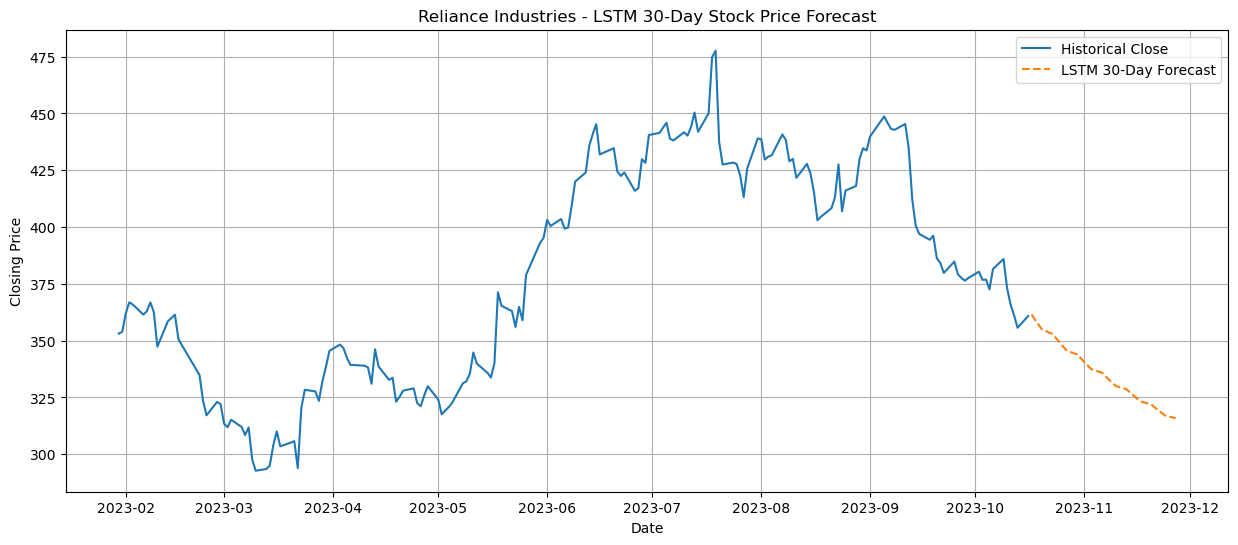

In [53]:
# Forecast visualization

plt.figure(figsize=(15, 6))

plt.plot(
    data.index[-180:],
    data['Close'].iloc[-180:],
    label='Historical Close'
)

plt.plot(
    forecast_df['Date'],
    forecast_df['Forecast_Close'],
    label='LSTM 30-Day Forecast',
    linestyle='--'
)

plt.title(
    'Reliance Industries - LSTM 30-Day Stock Price Forecast'
)

plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.legend()
plt.grid(True)

plt.show()

In [54]:
# Save the forecast

forecast_df.to_csv(
    'Reliance_LSTM_30_Day_Forecast.csv',
    index=False
)

In [55]:
# Save the LSTM model
final_lstm.save(
    "reliance_lstm_model.keras"
)

# Save the scaler
import joblib

joblib.dump(
    scaler,
    "reliance_stock_scaler.pkl"
)

print("LSTM model and scaler saved successfully.")

LSTM model and scaler saved successfully.


 I evaluated multiple forecasting models including Naive, ARIMA, SARIMA, Exponential Smoothing and LSTM. Based on the evaluation metrics MAE, RMSE and MAPE, LSTM achieved the best overall performance, so I selected LSTM as the final model. I then retrained the LSTM using the complete historical dataset and generated a recursive forecast for the next 30 trading days

# Streamlit Deployment

In [56]:
# app.py

In [57]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import joblib


# =========================================================
# PAGE CONFIGURATION
# =========================================================

st.set_page_config(
    page_title="Reliance Stock Forecasting",
    page_icon="📈",
    layout="wide"
)


# =========================================================
# CONFIGURATION
# =========================================================

MODEL_PATH = "reliance_lstm_model.keras"
SCALER_PATH = "reliance_stock_scaler.pkl"

SEQUENCE_LENGTH = 60
FORECAST_DAYS = 30


# =========================================================
# LOAD MODEL AND SCALER
# =========================================================

@st.cache_resource
def load_model_and_scaler():

    model = tf.keras.models.load_model(
        MODEL_PATH
    )

    scaler = joblib.load(
        SCALER_PATH
    )

    return model, scaler


try:

    model, scaler = load_model_and_scaler()

except FileNotFoundError:

    st.error(
        "❌ Model or scaler file not found."
    )

    st.info(
        "Keep the model and scaler in the same folder as app.py."
    )

    st.code(
        "reliance_lstm_model.keras\n"
        "reliance_stock_scaler.pkl"
    )

    st.stop()

except Exception as e:

    st.error(
        "❌ Unable to load the LSTM model or scaler."
    )

    st.exception(e)

    st.stop()


# =========================================================
# HEADER
# =========================================================

st.title(
    "📈 Reliance Stock Price Forecasting"
)

st.subheader(
    "LSTM-Based 30 Trading-Day Forecast"
)

st.write(
    "Forecast Reliance stock closing prices using "
    "the final trained LSTM model."
)

st.divider()


# =========================================================
# SIDEBAR
# =========================================================

st.sidebar.header(
    "📊 Forecast Settings"
)

st.sidebar.info(
    f"""
**Model:** LSTM

**Forecast Horizon:** {FORECAST_DAYS} Trading Days

**Sequence Length:** {SEQUENCE_LENGTH}

**Target:** Close Price
"""
)

st.sidebar.header(
    "📂 Upload Stock Data"
)

uploaded_file = st.sidebar.file_uploader(
    "Upload Reliance Stock Data",
    type=["csv", "xlsx"]
)


# =========================================================
# FILE CHECK
# =========================================================

if uploaded_file is None:

    st.info(
        "👈 Please upload your Reliance stock data."
    )

    st.stop()


# =========================================================
# READ CSV / EXCEL
# =========================================================

try:

    if uploaded_file.name.lower().endswith(".csv"):

        data = pd.read_csv(
            uploaded_file
        )

    else:

        data = pd.read_excel(
            uploaded_file
        )

except Exception as e:

    st.error(
        "❌ Unable to read the uploaded file."
    )

    st.exception(e)

    st.stop()


# =========================================================
# CLEAN COLUMN NAMES
# =========================================================

data.columns = (
    data.columns
    .str.strip()
)


# =========================================================
# FIND CLOSE COLUMN
# =========================================================

close_column = None

for column in [
    "Close",
    "close",
    "CLOSE",
    "Adj Close",
    "adj_close"
]:

    if column in data.columns:

        close_column = column

        break


if close_column is None:

    st.error(
        "❌ Close price column not found."
    )

    st.write(
        "Available columns:"
    )

    st.write(
        list(data.columns)
    )

    st.stop()


# =========================================================
# FIND DATE COLUMN
# =========================================================

date_column = None

for column in [
    "Date",
    "date",
    "DATE"
]:

    if column in data.columns:

        date_column = column

        break


# =========================================================
# PROCESS DATE
# =========================================================

if date_column is not None:

    data[date_column] = pd.to_datetime(
        data[date_column],
        errors="coerce"
    )

    data = data.dropna(
        subset=[date_column]
    )

    data = data.sort_values(
        date_column
    )


# =========================================================
# PROCESS CLOSE PRICE
# =========================================================

data[close_column] = pd.to_numeric(
    data[close_column],
    errors="coerce"
)

data = data.dropna(
    subset=[close_column]
)

data = data.reset_index(
    drop=True
)


# =========================================================
# DATA VALIDATION
# =========================================================

if len(data) < SEQUENCE_LENGTH:

    st.error(
        f"❌ At least {SEQUENCE_LENGTH} "
        "historical records are required."
    )

    st.stop()


# =========================================================
# HISTORICAL DATA
# =========================================================

st.subheader(
    "📋 Historical Stock Data"
)

st.dataframe(
    data.tail(10),
    use_container_width=True,
    hide_index=True
)


# =========================================================
# PREPARE CLOSE PRICES
# =========================================================

prices = data[
    [close_column]
].values


# =========================================================
# SCALE DATA
# =========================================================

try:

    scaled_data = scaler.transform(
        prices
    )

except Exception as e:

    st.error(
        "❌ Error while scaling the data."
    )

    st.info(
        "The scaler must be the same scaler used "
        "during LSTM training."
    )

    st.exception(e)

    st.stop()


# =========================================================
# FORECAST FUNCTION
# =========================================================

def generate_forecast():

    sequence = (
        scaled_data[
            -SEQUENCE_LENGTH:
        ].copy()
    )

    predictions = []

    for _ in range(
        FORECAST_DAYS
    ):

        X = sequence.reshape(
            1,
            SEQUENCE_LENGTH,
            1
        )

        prediction = model.predict(
            X,
            verbose=0
        )

        predicted_value = float(
            prediction[0][0]
        )

        predictions.append(
            predicted_value
        )

        sequence = np.concatenate(
            [
                sequence[1:],
                np.array(
                    [[predicted_value]]
                )
            ],
            axis=0
        )

    predictions = np.array(
        predictions
    ).reshape(
        -1,
        1
    )

    predictions = scaler.inverse_transform(
        predictions
    )

    return predictions.flatten()


# =========================================================
# FORECAST BUTTON
# =========================================================

if st.button(
    "🚀 Generate 30-Day Forecast",
    type="primary",
    use_container_width=True
):

    with st.spinner(
        "Generating LSTM forecast..."
    ):

        try:

            forecast = generate_forecast()

        except Exception as e:

            st.error(
                "❌ Forecast generation failed."
            )

            st.exception(e)

            st.stop()


    # =====================================================
    # LAST DATE
    # =====================================================

    if date_column is not None:

        last_date = data[
            date_column
        ].iloc[-1]

    else:

        last_date = pd.Timestamp.today()


    # =====================================================
    # FUTURE TRADING DAYS
    # =====================================================

    future_dates = pd.bdate_range(
        start=last_date + pd.Timedelta(days=1),
        periods=FORECAST_DAYS
    )


    # =====================================================
    # FORECAST DATAFRAME
    # =====================================================

    forecast_df = pd.DataFrame({

        "Date": future_dates,

        "Predicted Close Price": forecast

    })


    # =====================================================
    # FORECAST RESULTS
    # =====================================================

    st.subheader(
        "📊 Next 30 Trading-Day Forecast"
    )

    st.dataframe(
        forecast_df,
        use_container_width=True,
        hide_index=True
    )


    # =====================================================
    # METRICS
    # =====================================================

    last_price = float(
        prices[-1][0]
    )

    day_1_price = float(
        forecast[0]
    )

    day_30_price = float(
        forecast[-1]
    )

    percentage_change = (
        (day_30_price - last_price)
        / last_price
    ) * 100


    col1, col2, col3 = st.columns(3)


    with col1:

        st.metric(
            "Last Actual Price",
            f"₹{last_price:,.2f}"
        )


    with col2:

        st.metric(
            "Day 1 Forecast",
            f"₹{day_1_price:,.2f}"
        )


    with col3:

        st.metric(
            "Day 30 Forecast",
            f"₹{day_30_price:,.2f}",
            f"{percentage_change:.2f}%"
        )


    # =====================================================
    # CHART
    # =====================================================

    st.subheader(
        "📈 Historical vs LSTM Forecast"
    )

    fig, ax = plt.subplots(
        figsize=(14, 6)
    )

    historical = data.tail(120)

    if date_column is not None:

        ax.plot(
            historical[date_column],
            historical[close_column],
            label="Historical Price"
        )

        ax.plot(
            future_dates,
            forecast,
            linestyle="--",
            label="LSTM Forecast"
        )

    else:

        historical_x = np.arange(
            len(historical)
        )

        forecast_x = np.arange(
            len(historical),
            len(historical) + FORECAST_DAYS
        )

        ax.plot(
            historical_x,
            historical[close_column],
            label="Historical Price"
        )

        ax.plot(
            forecast_x,
            forecast,
            linestyle="--",
            label="LSTM Forecast"
        )


    ax.set_title(
        "Reliance Stock Price Forecast using LSTM"
    )

    ax.set_xlabel(
        "Date"
    )

    ax.set_ylabel(
        "Stock Price (₹)"
    )

    ax.legend()

    ax.grid(
        True,
        alpha=0.3
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    st.pyplot(
        fig
    )

    plt.close(
        fig
    )


    # =====================================================
    # DOWNLOAD FORECAST
    # =====================================================

    csv_data = forecast_df.to_csv(
        index=False
    )

    st.download_button(
        label="📥 Download Forecast CSV",
        data=csv_data,
        file_name="reliance_30_day_forecast.csv",
        mime="text/csv",
        use_container_width=True
    )

    st.success(
        "✅ 30-trading-day forecast generated successfully!"
    )


# =========================================================
# MODEL INFORMATION
# =========================================================

st.divider()

st.subheader(
    "🤖 Model Information"
)

col1, col2, col3 = st.columns(3)

with col1:

    st.info(
        "**Model**\n\nLSTM"
    )

with col2:

    st.info(
        "**Forecast Horizon**\n\n30 Trading Days"
    )

with col3:

    st.info(
        f"**Sequence Length**\n\n{SEQUENCE_LENGTH}"
    )


# =========================================================
# DEVELOPED BY
# =========================================================
# =========================================================
# DEVELOPED BY
# =========================================================

st.divider()

st.markdown(
    """
    ### 👨‍💻 Developed By

    **PALSA MANOJ KUMAR**

    📧 **Email:** [palsamanojkumar@gmail.com](mailto:palsamanojkumar@gmail.com)

    🔗 **GitHub:** [palsamanojkumar-07](https://github.com/palsamanojkumar-07)
    """
)

st.caption(
    "© 2026 PALSA MANOJ KUMAR | Reliance Stock Price Forecasting"
)


# =========================================================
# DISCLAIMER
# =========================================================

st.warning(
    "⚠️ Disclaimer: This application is developed for "
    "educational and research purposes only. The forecasts "
    "are generated by a machine learning model and should "
    "not be considered financial or investment advice."
)

2026-08-22 23:15:43.608 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-22 23:15:43.615 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-22 23:15:47.892 
  command:

    streamlit run C:\Users\PALSA MANOJ KUMAR\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-08-22 23:15:47.895 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-22 23:15:47.899 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-22 23:15:48.329 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-22 23:15:48.332 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor

DeltaGenerator()

In [58]:
# Display the Absolute Path of app.py File
import os
print(os.path.abspath("app.py"))

C:\Users\PALSA MANOJ KUMAR\Project\app.py


# requirements.txt

* streamlit
* pandas
* numpy
* matplotlib
* tensorflow
* scikit-learn
* joblib

In [59]:
# Run Streamlit
# streamlit run app.py

# Conclusion

* The Reliance Stock Price Forecasting project successfully developed and evaluated multiple time-series forecasting models, including Naive, ARIMA, SARIMA, Exponential Smoothing, and LSTM. Based on the evaluation metrics MAE, RMSE, and MAPE, the LSTM model was selected as the best-performing model.

* The final LSTM model was retrained using the complete historical dataset and used to generate forecasts for the next 30 trading days. The model was saved and integrated into a Streamlit web application, allowing users to upload historical stock data in CSV or Excel format and generate forecasts interactively.

* Overall, this project demonstrates the application of time-series analysis, deep learning, model evaluation, and Streamlit deployment for stock price forecasting. The developed application provides an easy-to-use interface for visualizing historical prices and predicted future prices.